Great question! Comparing the **Cox Proportional Hazards (CoxPH) model** to a **Transformer model trained with a Cox loss** is a natural extension of benchmarking traditional survival analysis against modern deep learning approaches.

Below is a guide on how to do this, including a plan, code sketch, and options for going deeper.

---

## 1. 🧩 Overview of the Task

You want to:

| Goal         | Model                                                                               |
| ------------ | ----------------------------------------------------------------------------------- |
| **Baseline** | Classical CoxPH (e.g., from `lifelines` or `scikit-survival`)                       |
| **Neural**   | Transformer-based model trained with a **partial likelihood loss** (i.e., Cox loss) |

---

### 2. **Baseline: CoxPH using `lifelines`**

```python
from lifelines import CoxPHFitter
import pandas as pd

def fit_coxph_lifelines(X, T, E):
    df = pd.DataFrame(X.numpy(), columns=[f'x{i}' for i in range(X.shape[1])])
    df['T'] = T.numpy()
    df['E'] = E.numpy()
    cph = CoxPHFitter()
    cph.fit(df, duration_col='T', event_col='E')
    return cph
```

---

### 3. **Transformer Model with Cox Loss**

We use **negative partial log-likelihood** from Cox:

$$
\mathcal{L}_{\text{Cox}} = - \sum_{i: \delta_i = 1} \left[ \eta_i - \log \sum_{j \in R_i} e^{\eta_j} \right]
$$

Where:

* $\eta_i = \text{log-risk}$ output by model
* $R_i = \{ j : T_j \geq T_i \}$

#### 🔧 Cox Loss in PyTorch

```python
def cox_loss(log_hazard, times, events):
    # Sort by decreasing time
    order = torch.argsort(times, descending=False)
    log_hazard = log_hazard[order]
    events = events[order]
    risk = log_hazard
    hazard_ratio = torch.exp(risk)
    log_cumsum = torch.log(torch.cumsum(hazard_ratio.flip(0), dim=0).flip(0))
    uncensored_likelihood = risk - log_cumsum
    loss = -torch.sum(uncensored_likelihood * events) / events.sum()
    return loss
```

#### 🔧 Transformer model for log-risk prediction:

```python
class CoxTransformer(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=4, num_layers=1):
        super().__init__()
        self.embed = nn.Linear(1, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)  # (batch, input_dim, 1)
        x = self.embed(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch, d_model)
        x = self.encoder(x)
        x = x.mean(dim=0)
        return self.out(x).squeeze(-1)  # (batch,)
```

---

### 4. **Training Loop**

```python
def train_cox_transformer(model, X, T, E, epochs=100, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        log_risk = model(X)
        loss = cox_loss(log_risk, T, E)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
```

---

### 5. **Evaluation: Concordance Index (C-index)**

Use `lifelines.utils.concordance_index`:

```python
from lifelines.utils import concordance_index

def cindex_transformer(log_risk, T, E):
    return concordance_index(T.detach().numpy(), -log_risk.detach().numpy(), E.numpy())
```

---

## ✅ Summary of Comparisons

| Metric               | CoxPH (`lifelines`)    | Transformer (Cox loss) |
| -------------------- | ---------------------- | ---------------------- |
| C-index              | ✅ fast + interpretable | ✅ more flexible        |
| Handles nonlinearity | ❌                      | ✅                      |
| Needs tuning         | Minimal                | Yes (layers, lr, etc.) |

---


| Goal         | Model                                                                               |
| ------------ | ----------------------------------------------------------------------------------- |
| **Baseline** | Classical CoxPH (e.g., from `lifelines` or `scikit-survival`)                       |
| **Neural**   | Transformer-based model trained with a **partial likelihood loss** (i.e., Cox loss) |


!pip install pycox

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import time
import lifelines
import random
from lifelines.utils import concordance_index
import lifelines
from lifelines import CoxPHFitter

In [5]:
import pandas as pd

In [6]:
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from pycox.datasets import metabric

# 1 Toy survival data generation (X, T, E)

https://github.com/dianashams/simulating_survival_data_python/blob/main/Simulated_Data_for_Survival_Analysis.ipynb

In [7]:
def sim1(N=1000, observe_time =10, percentcensored = 0.2, randomseed = 100):
    # N - population size
    # observe_time - total observation time, after which all survivors are right-censored 
    # percentcensored - rate of dropping out early from the observation
    # this censoring is applied unformly from 0 to 10, so for those who had the event before dropping out, 
    # would not be censored in terms of the censoring definition, and actual drop out rate <= percentcencored
    #randomseed - random seed for population simulation, set before applying numpy.random functions
    
    #check that inputs are of the right type
    c1 = isinstance(N,int)
    c2 = (isinstance(observe_time, float)|isinstance(observe_time, int))
    c3 = (isinstance(percentcensored, float)|isinstance(percentcensored, int))
    if (isinstance(percentcensored, float)|isinstance(percentcensored, int)): 
        if((percentcensored>=1)|(percentcensored<0)): 
            c3= False
    c4 = isinstance(randomseed,int)
        
    if (c1&c2&c3&c4 == False): 
        c= [c1,c2,c3,c4] 
        b = ["N", "observe_time", "percentcensored", "randomseed"]
        print ("Error with input type:", [b[i] for i in range(len(c)) if c[i]==False])
        return None 
    
    #start simulations 
    random.seed(randomseed)
    
    #1_ generating main features:
    df = pd.DataFrame({"age": np.round(np.random.uniform(-1.73,1.73,N),1),
                  "bmi": np.round(np.random.normal(0, 1,N),1),  
                  "hyp": np.random.binomial(1,0.20, N),
                  "gender": np.random.binomial(1,0.5, N)})
    
    #2_ generating event times: 
    df["event_time"] = 0.01 + np.round(np.random.exponential(1/(0.1*np.exp(1.0*df.bmi + 
                                      df.hyp*0.7 + df.age*0.4)),N),2)
    df["observe_time"] = observe_time
    
    #3_ add censored observations with a shorter observation time (drop-outs)
    # the time is randomly drawn uniformly from observe_time/20 to observe_time ('/20' to exclude very short observations)
    df["early_censored"]=0 #marker if an observation dropped out early (1) 
    if (percentcensored > 0):
        #assume that nobody drops out in the first 1/20th of the observation time 
        randcentime = np.random.uniform(observe_time/20, observe_time, int(N*percentcensored))
        cens_obs = np.random.choice(df.shape[0], int(N*percentcensored), replace = False)
        # censored time is the end of observation in this simulation
        df["cens_time"]= np.nan
        df.loc[cens_obs, "cens_time"] = randcentime
        df.loc[~ df.index.isin(cens_obs), "cens_time"] = observe_time
        
        #change early censored to 1 for those dropped out before event and before observation end:
        df.loc[((df["cens_time"] < df["observe_time"]) & 
                (df["cens_time"] < df["event_time"])), "early_censored"]=1  
    else: 
        df["cens_time"] = observe_time
    
    #4_ defining the outcome and time 
    # time is the first from event, censoring, or end of observation
    df["time"] = df[['event_time','cens_time','observe_time']].min(axis=1)
    
    # event is 1 if event happened before "time"
    df.loc[df.event_time<= df.time, "event"] = 1
    df.loc[df.event_time > df.time, "event"] = 0
    
    # delete redundant columns 
    df = df.drop(columns = ["cens_time", "event_time", "observe_time", "early_censored"])

    # alternatively - return (df) 
    
    # Automatically select all columns except 'time' and 'event'
    feature_df = df.drop(columns=['time', 'event'])    
    # Convert to PyTorch tensors
    X = torch.tensor(feature_df.values, dtype=torch.float32)
    T = torch.tensor(df['time'].values, dtype=torch.float32)
    E = torch.tensor(df['event'].values, dtype=torch.float32)    
    
    return (X, T, E)

In [8]:
def sim2(N=1000, observe_time =10, percentcensored = 0.2, randomseed = 100):
    # N - population size
    # observe_time - total observation time, after which all survivors are right-censored 
    # percentcensored - rate of dropping out early from the observation
    # this censoring is applied unformly from 0 to 10, so for those who had the event before dropping out, 
    # would not be censored in terms of the censoring definition, and actual drop out rate <= percentcencored
    #randomseed - random seed for population simulation, set before applying numpy.random functions
    
    #check that inputs are of the right type
    c1 = isinstance(N,int)
    c2 = (isinstance(observe_time, float)|isinstance(observe_time, int))
    c3 = (isinstance(percentcensored, float)|isinstance(percentcensored, int))
    if (isinstance(percentcensored, float)|isinstance(percentcensored, int)): 
        if((percentcensored>=1)|(percentcensored<0)): 
            c3= False
    c4 = isinstance(randomseed,int)
        
    if (c1&c2&c3&c4 == False): 
        c= [c1,c2,c3,c4] 
        b = ["N", "observe_time", "percentcensored", "randomseed"]
        print ("Error with input type:", [b[i] for i in range(len(c)) if c[i]==False])
        return None 
    
    #start simulations 
    random.seed(randomseed)
    
    #1_ generating main features:
    df = pd.DataFrame({"age": np.round(np.random.uniform(-1.73,1.73,N),1),
                  "bmi": np.round(np.random.normal(0, 1,N),1),  
                  "hyp": np.random.binomial(1,0.20, N),
                  "gender": np.random.binomial(1,0.5, N)})
    
    #2_ generating event times: 
    #BMI impact is 2 for very low and high levels, 1 for high/ low level, 0 for normal range
    bmi_beta = np.array([2 if (np.abs(x)> 1.5) else 1 if (np.abs(x)>1) else 0 for x in df["bmi"]])

    #Age impact is 1 for age>=55; linear age impact is also present, but is smaller than in linear simulation
    age_beta = np.array([1 if (x >=1) else 0 for x in df["age"]])
    
    # simulating event time
    df["event_time"] = 0.01+ np.round(np.random.exponential(1/(0.08*np.exp(bmi_beta + 
                                      (df.hyp*0.7)+ df.age*0.2 + age_beta)),N),2)
    df["observe_time"] = observe_time
    
    #3_ add censored observations with a shorter observation time (drop-outs)
    # the time is randomly drawn uniformly from observe_time/20 to observe_time ('/20' to exclude very short observations)
    df["early_censored"]=0 #marker if an observation dropped out early (1) 
    if (percentcensored > 0):
        #assume that nobody drops out in the first 1/20th of the observation time 
        randcentime = np.random.uniform(observe_time/20, observe_time, int(N*percentcensored))
        cens_obs = np.random.choice(df.shape[0], int(N*percentcensored), replace = False)
        # censored time is the end of observation in this simulation
        df["cens_time"]= np.nan
        df.loc[cens_obs, "cens_time"] = randcentime
        df.loc[~ df.index.isin(cens_obs), "cens_time"] = observe_time
        
        #change early censored to 1 for those dropped out before event and before observation end:
        df.loc[((df["cens_time"] < df["observe_time"]) & 
                (df["cens_time"] < df["event_time"])), "early_censored"]=1  
    else: 
        df["cens_time"] = observe_time
    
    #4_ defining the outcome and time 
    # time is the first from event, censoring, or end of observation
    df["time"] = df[['event_time','cens_time','observe_time']].min(axis=1)
    
    # event is 1 if event happened before "time"
    df.loc[df.event_time<= df.time, "event"] = 1
    df.loc[df.event_time > df.time, "event"] = 0
    
    # delete redundant columns 
    df = df.drop(columns = ["cens_time", "event_time", "observe_time", "early_censored"])

    # alternatively - return (df) 
    
    # Automatically select all columns except 'time' and 'event'
    feature_df = df.drop(columns=['time', 'event'])    
    # Convert to PyTorch tensors
    X = torch.tensor(feature_df.values, dtype=torch.float32)
    T = torch.tensor(df['time'].values, dtype=torch.float32)
    E = torch.tensor(df['event'].values, dtype=torch.float32)    
    
    return (X, T, E)

In [9]:
def sim3 (N = 1000, observe_time = 10, percentcensored = 0.2, randomseed = 100):
    # N - population size
    # observe_time - total observation time, after which all survivors are right-censored 
    # percentcensored - rate of dropping out early from the observation
    # this censoring is applied unformly from 0 to 10, so for those who had the event before dropping out, 
    # would not be censored in terms of the censoring definition, and actual drop out rate <= percentcencored
    #randomseed - random seed for population simulation, set before applying numpy.random functions
    
    #check that inputs are of the right type
    c1 = isinstance(N,int)
    c2 = (isinstance(observe_time, float)|isinstance(observe_time, int))
    c3 = (isinstance(percentcensored, float)|isinstance(percentcensored, int))
    if (isinstance(percentcensored, float)|isinstance(percentcensored, int)): 
        if((percentcensored>=1)|(percentcensored<0)): 
            c3= False
    c4 = isinstance(randomseed,int)
    if (c1&c2&c3&c4 == False): 
        c= [c1,c2,c3,c4] 
        b = ["N", "observe_time", "percentcensored", "randomseed"]
        print ("Error with input type:", [b[i] for i in range(len(c)) if c[i]==False])
        return None 
    
    #start simulations 
    random.seed(randomseed)
    
    #1_ generating main features:
    df = pd.DataFrame({"age": np.round(np.random.uniform(-1.73,1.73,N),1),
                  "bmi": np.round(np.random.normal(0, 1,N),1),  
                  "hyp": np.random.binomial(1,0.20, N),
                  "gender": np.random.binomial(1,0.5, N)})
    
    #2_ generating event times: 
    #BMI impact is 2 for very low and high levels, 1 for high/ low level, 0 for normal range
    bmi_beta = np.array([2 if (np.abs(x)> 1.5) else 1 if (np.abs(x)>1) else 0 for x in df["bmi"]])  
    
    # hypertension x age interaction
    hyp_age_beta = np.array([2 if ((df.loc[i,"age"]>=1) & (df.loc[i,"hyp"]==1))
                        else 1 if ((df.loc[i,"age"]<1)&(df.loc[i,"hyp"]==1)) 
                                else 0 for i in range(df.shape[0])])

    # simulating event time
    df["event_time"] = 0.01 + np.round(np.random.exponential(1/(0.07*np.exp(bmi_beta + 
                                      hyp_age_beta + df["age"]*0.2)),N),2)
    
    df["observe_time"] = observe_time

    #3_ add censored observations with a shorter observation time (drop-outs)
    # the time is randomly drawn uniformly from observe_time/20 to observe_time ('/20' to exclude very short observations)
    df["early_censored"]=0 #marker if an observation dropped out early (1) 
    if (percentcensored > 0):
        #assume that nobody drops out in the first 1/20th of the observation time 
        randcentime = np.random.uniform(observe_time/20, observe_time, int(N*percentcensored))
        cens_obs = np.random.choice(df.shape[0], int(N*percentcensored), replace = False)
        # censored time is the end of observation in this simulation
        df["cens_time"]= np.nan
        df.loc[cens_obs, "cens_time"] = randcentime
        df.loc[~ df.index.isin(cens_obs), "cens_time"] = observe_time
        
        #change early censored to 1 for those dropped out before event and before observation end:
        df.loc[((df["cens_time"] < df["observe_time"]) & 
                (df["cens_time"] < df["event_time"])), "early_censored"]=1  
    else: 
        df["cens_time"] = observe_time
    
    #4_ defining the outcome and time 
    # time is the first from event, censoring, or end of observation
    df["time"] = df[['event_time','cens_time','observe_time']].min(axis=1)
    
    # event is 1 if event happened before "time"
    df.loc[df.event_time<= df.time, "event"] = 1
    df.loc[df.event_time > df.time, "event"] = 0
    
    # delete redundant columns 
    df = df.drop(columns = ["cens_time", "event_time", "observe_time", "early_censored"])

    # alternatively - return (df) 
    
    # Automatically select all columns except 'time' and 'event'
    feature_df = df.drop(columns=['time', 'event'])    
    # Convert to PyTorch tensors
    X = torch.tensor(feature_df.values, dtype=torch.float32)
    T = torch.tensor(df['time'].values, dtype=torch.float32)
    E = torch.tensor(df['event'].values, dtype=torch.float32)    
    
    return (X, T, E)

# 2 Vanilla CoxPH model from Lifelines

In [27]:

def cindex_cph(cph_model, df):
    dffit = pd.DataFrame(df[0].numpy(), columns=[f'x{i}' for i in range(df[0].shape[1])])
    dffit['time'] = df[1].numpy()
    dffit['event'] = df[2].numpy()
    risk_scores = -cph_model.predict_partial_hazard(dffit)  # higher score = longer survival
    return concordance_index(dffit['time'], risk_scores, dffit['event'])

def risk_cph(cph_model, df):
    dffit = pd.DataFrame(df[0].numpy(), columns=[f'x{i}' for i in range(df[0].shape[1])])
    dffit['time'] = df[1].numpy()
    dffit['event'] = df[2].numpy()
    risk_scores = -cph_model.predict_partial_hazard(dffit)  # higher score = longer survival
    return risk_scores

def fit_coxph_lifelines(df):
    dffit = pd.DataFrame(df[0].numpy(), columns=[f'x{i}' for i in range(df[0].shape[1])])
    dffit['time'] = df[1].numpy()
    dffit['event'] = df[2].numpy()
    cph = CoxPHFitter()
    cph.fit(dffit, duration_col='time', event_col='event')
    print(cindex_cph(cph, df))
    return cph


In [28]:
# simple test 
df2 = sim3(N = 1000, randomseed = 41) # generated data
df2_test = sim3(N = 1000, randomseed = 41) # 
coxm2 = fit_coxph_lifelines(df2)  #fit the model
c2 = cindex_cph(coxm2, df2_test) # get test c-index
c2

0.6297831863827149


0.6062079146002705

# 3 NN CoxPH 
// can also try CoxPH from pycox later, doesnt work a hybrid version yet //

In [34]:
def cindex_transformer(model, df):
    model.eval()
    risk_score = -1*model(df[0]).squeeze().detach().numpy()
    c = concordance_index(df[1].numpy(), risk_score, df[2].numpy())
    return c

In [35]:
def cox_loss(log_hazard, times, events):
    # Sort by decreasing time
    order = torch.argsort(times, descending = False)
    log_hazard = log_hazard[order]
    events = events[order]
    hazard_ratio = torch.exp(log_hazard)
    log_cumsum = torch.log(torch.cumsum(hazard_ratio.flip(0), dim=0).flip(0))
    uncensored_likelihood = log_hazard - log_cumsum
    loss = - torch.sum(uncensored_likelihood * events) / events.sum()
    return loss

In [36]:
class CoxNN(nn.Module):
    def __init__(self, input_dim, d_model=16):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, d_model)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(d_model, d_model)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(d_model, 1)
        
    def forward(self, x):
        # x: (batch_size, input_dim)
        x = self.fc1(x)  # (batch_size, input_dim, d_model)
        x = self.relu(x)
        x = self.fc2(x)  # (batch_size, input_dim, d_model)
        x = self.relu2(x)
        return self.output(x).squeeze(-1)  # (batch_size,)

In [37]:
def train_cox_transformer(model, df, dftest, n_epochs=100, lr=1e-3, batch_size = 32):
    c0 = cindex_transformer(model, dftest)
    train_loader = DataLoader(TensorDataset(df[0], df[1], df[2]), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    cind = []
    start = time.time()
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for xx, tt, ee in train_loader:
            log_risk = model(xx)
            loss = cox_loss(log_risk, tt, ee)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss * xx.size(0)
        #train_losses.append(total_loss / len(train_loader.dataset))
        if (epoch < 10): print(f"Epoch {epoch+1}/{n_epochs} | Loss: {total_loss:.4f}")
        if (epoch%10 == 0): 
            print(f"Epoch {epoch+1}/{n_epochs} | Loss: {total_loss:.4f} ")
            #print(f"C-index Train/test {cindex_transformer(model, df):.4f}/{cindex_transformer(model, dftest):.4f}")
            #cind.append(cindex_transformer(model, dftest))
    end = time.time()
    print(f"time, {end-start} sec")
    print(f"C-index Before training test/Train/test {c0:.4f}/{cindex_transformer(model, df):.4f}/{cindex_transformer(model, dftest):.4f}")
    #return cind

In [56]:
# test
# Simulating data (sim3 - xterms)
df = sim3(N=1000)
dftest = sim3(N=5000)
# CoxPH baseline
coxm = fit_coxph_lifelines(df)
#coxm.print_summary()
cindex_cph(coxm, dftest) # get test c-index


0.6224570268753539


0.6094371872313686

In [57]:
modeln = CoxNN(df[0].shape[1])
train_cox_transformer(modeln, df, dftest, n_epochs=50, lr=1e-3, batch_size = 128)

Epoch 1/50 | Loss: 4337.9604
Epoch 1/50 | Loss: 4337.9604 
Epoch 2/50 | Loss: 4329.3364
Epoch 3/50 | Loss: 4317.6587
Epoch 4/50 | Loss: 4308.0020
Epoch 5/50 | Loss: 4302.2607
Epoch 6/50 | Loss: 4293.5469
Epoch 7/50 | Loss: 4285.8550
Epoch 8/50 | Loss: 4277.3721
Epoch 9/50 | Loss: 4269.7734
Epoch 10/50 | Loss: 4259.9849
Epoch 11/50 | Loss: 4251.4556 
Epoch 21/50 | Loss: 4111.8301 
Epoch 31/50 | Loss: 4027.0664 
Epoch 41/50 | Loss: 4008.2358 
time, 0.40386390686035156 sec
C-index Before training test/Train/test 0.4040/0.7173/0.6946


# 4 Transformer CoxPH

In [58]:
class CoxTransformer(nn.Module):
    def __init__(self, input_dim, d_model=16, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, 1)    
    def forward(self, x):
        # x: (batch_size, input_dim)
        x = x.unsqueeze(-1)  # (batch_size, input_dim, 1)
        x = self.embedding(x)  # (batch_size, input_dim, d_model)
        x = x.permute(1, 0, 2)  # (seq_len, batch_size, d_model)
        x = self.transformer(x)  # (seq_len, batch_size, d_model)
        x = x.mean(dim=0)  # Mean pooling: (batch_size, d_model)
        return self.output(x).squeeze(-1)  # (batch_size,)

# Example

In [59]:
# Simulating data (sim3 - xterms)
df = sim3(N=10000)
dftest = sim3(N=5000)

In [60]:
# CoxPH baseline
coxm = fit_coxph_lifelines(df)
#coxm.print_summary()
c1_coxph = cindex_cph(coxm, dftest) # get test c-index
c1_coxph

0.6211187970959385


0.616341156669183

In [62]:
# CoxPH transformer 
transm = CoxTransformer(input_dim = df[0].shape, d_model=32, nhead=2, num_layers=2)

In [63]:
#Train the model
train_cox_transformer(transm, df, dftest, n_epochs=20, lr=1e-3, batch_size = 512)

Epoch 1/20 | Loss: 56028.5430
Epoch 1/20 | Loss: 56028.5430 
Epoch 2/20 | Loss: 55713.1875
Epoch 3/20 | Loss: 55660.0469
Epoch 4/20 | Loss: 55623.4805
Epoch 5/20 | Loss: 55582.3086
Epoch 6/20 | Loss: 55557.1055
Epoch 7/20 | Loss: 55589.4375
Epoch 8/20 | Loss: 55529.8672
Epoch 9/20 | Loss: 55539.5938
Epoch 10/20 | Loss: 55493.5352
Epoch 11/20 | Loss: 55495.6562 
time, 19.604623794555664 sec
C-index Before training test/Train/test 0.4948/0.6633/0.6543


In [64]:
#Train CoxNN model
modeln = CoxNN(df[0].shape[1])
train_cox_transformer(modeln, df, dftest, n_epochs=50, lr=1e-3, batch_size = 128)

Epoch 1/50 | Loss: 43163.9180
Epoch 1/50 | Loss: 43163.9180 
Epoch 2/50 | Loss: 42180.0078
Epoch 3/50 | Loss: 41381.8086
Epoch 4/50 | Loss: 41009.6914
Epoch 5/50 | Loss: 40906.9531
Epoch 6/50 | Loss: 40859.3750
Epoch 7/50 | Loss: 40802.9570
Epoch 8/50 | Loss: 40769.9688
Epoch 9/50 | Loss: 40757.2461
Epoch 10/50 | Loss: 40745.5859
Epoch 11/50 | Loss: 40760.2227 
Epoch 21/50 | Loss: 40691.1680 
Epoch 31/50 | Loss: 40607.4727 
Epoch 41/50 | Loss: 40538.2852 
time, 3.8811728954315186 sec
C-index Before training test/Train/test 0.5003/0.7134/0.7074


In [71]:
risk_score0 = risk_cph(coxm, df)

In [72]:
risk_score1 = -1*modeln(df[0]).squeeze().detach().numpy()

In [73]:
risk_score2 = -1*transm(df[0]).squeeze().detach().numpy()

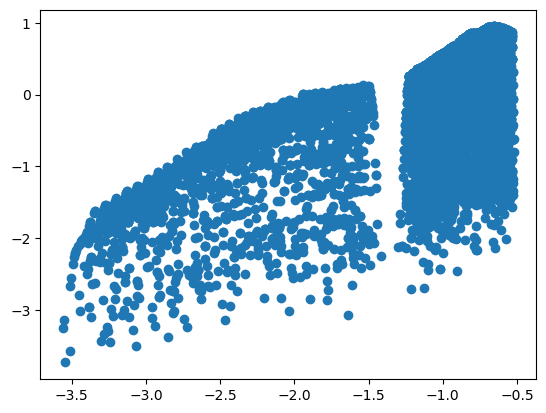

In [75]:
plt.scatter(risk_score0, risk_score1)

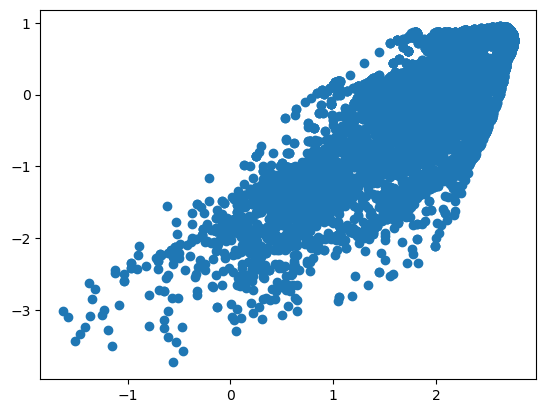

In [76]:
plt.scatter(risk_score2, risk_score1)